## Phase 3: Team Tactical Dynamics 🇦🇷 vs 🇫🇷
> "Individual brilliance wins games, but structured systems win World Cups."

In this section, we move from individual player analysis to **Team-level metrics**. We will compare Argentina and France in terms of shot quality (xG) and territorial dominance.

Connecting to StatsBomb... Fetching Match Events for Team Analysis.


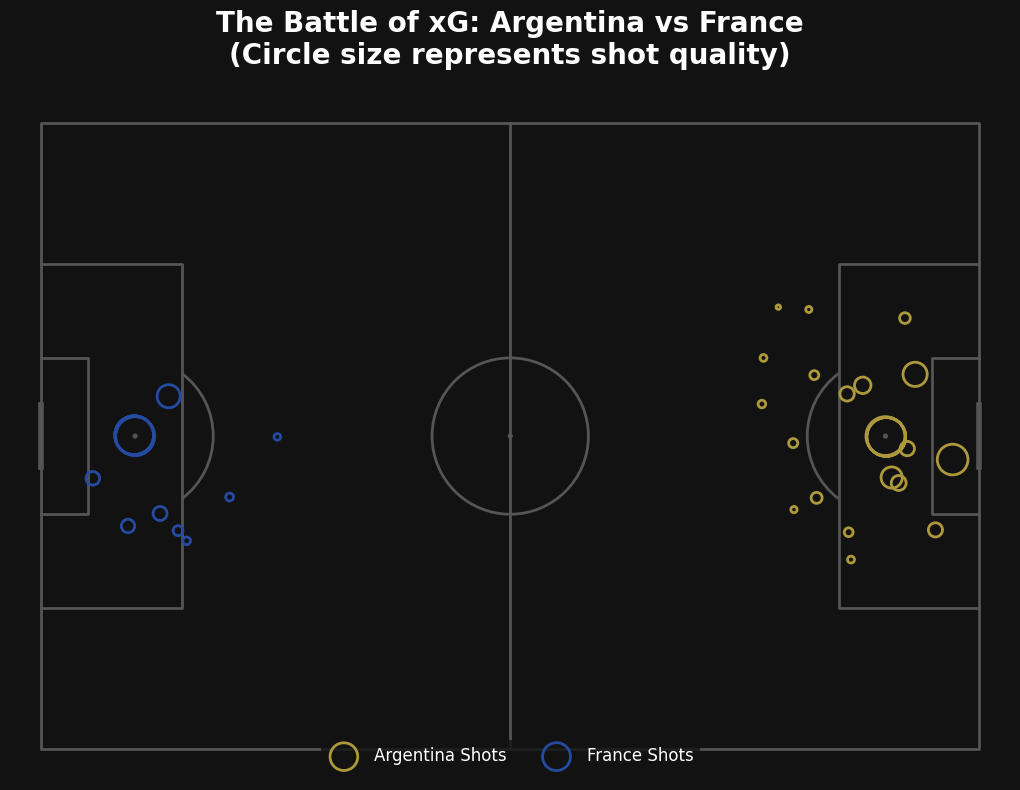

In [4]:
from statsbombpy import sb
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fetch data for the new notebook context
MATCH_ID = 3869685
print("Connecting to StatsBomb... Fetching Match Events for Team Analysis.")
events = sb.events(match_id=MATCH_ID)

# 2. Filter all shots from the match
shots = events[events.type == 'Shot'].copy()

# 3. Extract X, Y coordinates and xG values
shots['x'] = shots.location.apply(lambda loc: loc[0])
shots['y'] = shots.location.apply(lambda loc: loc[1])

# 4. Setup the pitch (Professional Dark Theme)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#121212', line_color='#555555')
fig, ax = pitch.draw(figsize=(13, 8))
fig.set_facecolor('#121212')

# 5. Plot Argentina Shots (Left Side)
arg_shots = shots[shots.team == 'Argentina']
pitch.scatter(arg_shots.x, arg_shots.y, 
              s=arg_shots.shot_statsbomb_xg * 1000, 
              edgecolors='#ad993c', facecolors='none', linewidth=2,
              label='Argentina Shots', ax=ax)

# 6. Plot France Shots (Right Side - Flipped)
fra_shots = shots[shots.team == 'France']
pitch.scatter(120 - fra_shots.x, 80 - fra_shots.y, 
              s=fra_shots.shot_statsbomb_xg * 1000, 
              edgecolors='#244ba0', facecolors='none', linewidth=2,
              label='France Shots', ax=ax)

# 7. Add Title and Legend
plt.title("The Battle of xG: Argentina vs France\n(Circle size represents shot quality)", 
          color='white', size=20, pad=20, weight='bold')
plt.legend(loc='lower center', facecolor='#121212', edgecolor='none', 
           labelcolor='white', fontsize=12, ncol=2)

plt.show()

## Phase 4: Team Passing Network (The Interaction Map)
> "Football is a game of connections. If the links are strong, the system is unbreakable."

In this section, we visualize the **Passing Network** for Argentina. This map shows:
1. **Node Size:** Represents the number of involvements (more touches = larger circle).
2. **Line Thickness:** Represents the volume of passes between two players.
3. **Player Position:** The average location of each player during their time on the pitch.

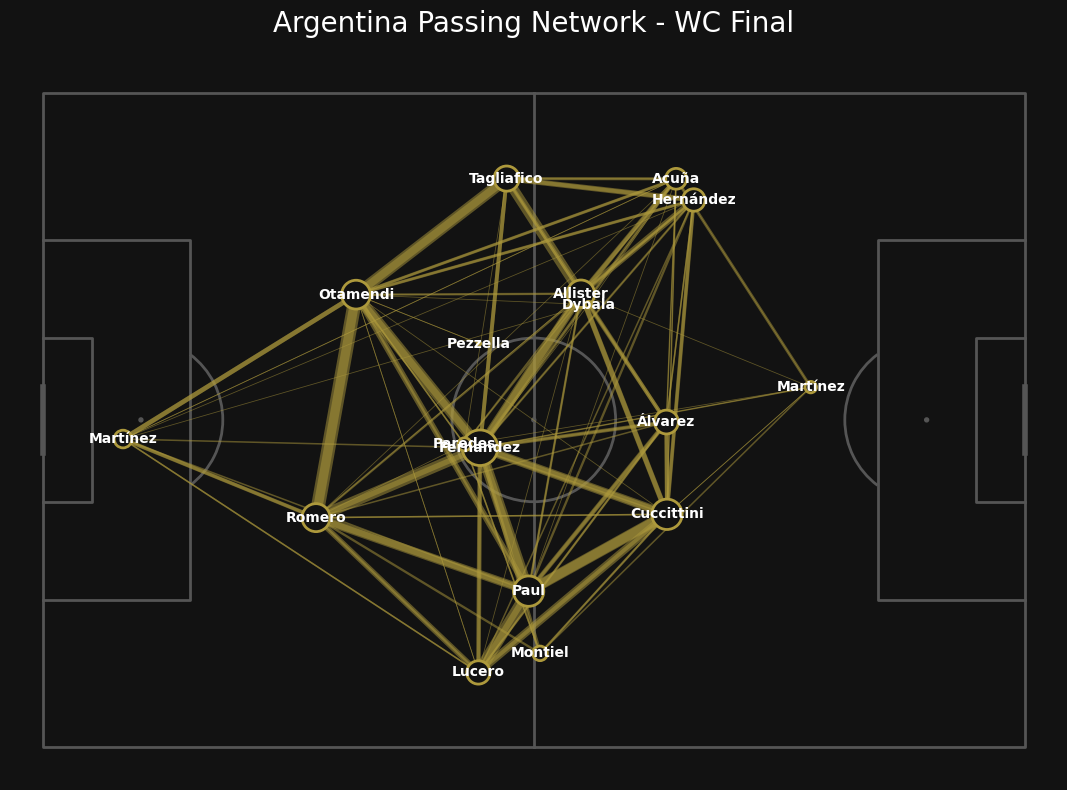

In [5]:
import numpy as np

# 1. Prepare the data for Passing Network
# We'll focus on Argentina's starters before the first substitution to keep it clean
team_name = 'Argentina'
df_pass = events[(events.type == 'Pass') & (events.team == team_name) & (events.pass_outcome.isna())].copy()

# Calculate average positions and pass counts
# We need to extract X and Y for all events first
events['x'] = events.location.apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
events['y'] = events.location.apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)

# Grouping by player to get average positions
avg_locations = events[events.team == team_name].groupby('player').agg({'x': ['mean'], 'y': ['mean', 'count']})
avg_locations.columns = ['x', 'y', 'count']

# Filter passes between players
pass_between = df_pass.groupby(['player', 'pass_recipient']).id.count().reset_index()
pass_between.rename(columns={'id': 'pass_count'}, inplace=True)

# Merge with average locations
pass_between = pass_between.merge(avg_locations, left_on='player', right_index=True)
pass_between = pass_between.merge(avg_locations, left_on='pass_recipient', right_index=True, suffixes=('', '_end'))

# 2. Setup the Pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#121212', line_color='#555555')
fig, ax = pitch.draw(figsize=(13, 8))
fig.set_facecolor('#121212')

# 3. Plot the lines (Passes between players) - only show strong connections (> 3 passes)
weights = pass_between.pass_count / pass_between.pass_count.max()
pitch.lines(pass_between.x, pass_between.y, pass_between.x_end, pass_between.y_end,
            lw=weights*10, color='#ad993c', alpha=0.5, zorder=1, ax=ax)

# 4. Plot the nodes (Player average positions)
nodes = pitch.scatter(avg_locations.x, avg_locations.y, s=avg_locations['count']*2,
                      color='#121212', edgecolors='#ad993c', linewidth=2, alpha=1, zorder=2, ax=ax)

# 5. Add player names (The labels)
for index, row in avg_locations.iterrows():
    pitch.annotate(index.split()[-1], xy=(row.x, row.y), c='white', va='center',
                   ha='center', size=10, weight='bold', ax=ax)

plt.title(f"{team_name} Passing Network - WC Final", color='white', size=20, pad=20)
plt.show()

## 🇫🇷 Phase 5: Opposition Analysis - France's Passing Structure
> "To understand the victory, we must analyze the resistance."

We now generate the passing network for **France**. This allows us to compare:
1. **Progression Patterns:** Did France rely more on Mbappe's wing or central play?
2. **Compactness:** How stretched was the French team compared to Argentina?
3. **Key Links:** Who were the primary distributors for Les Bleus?

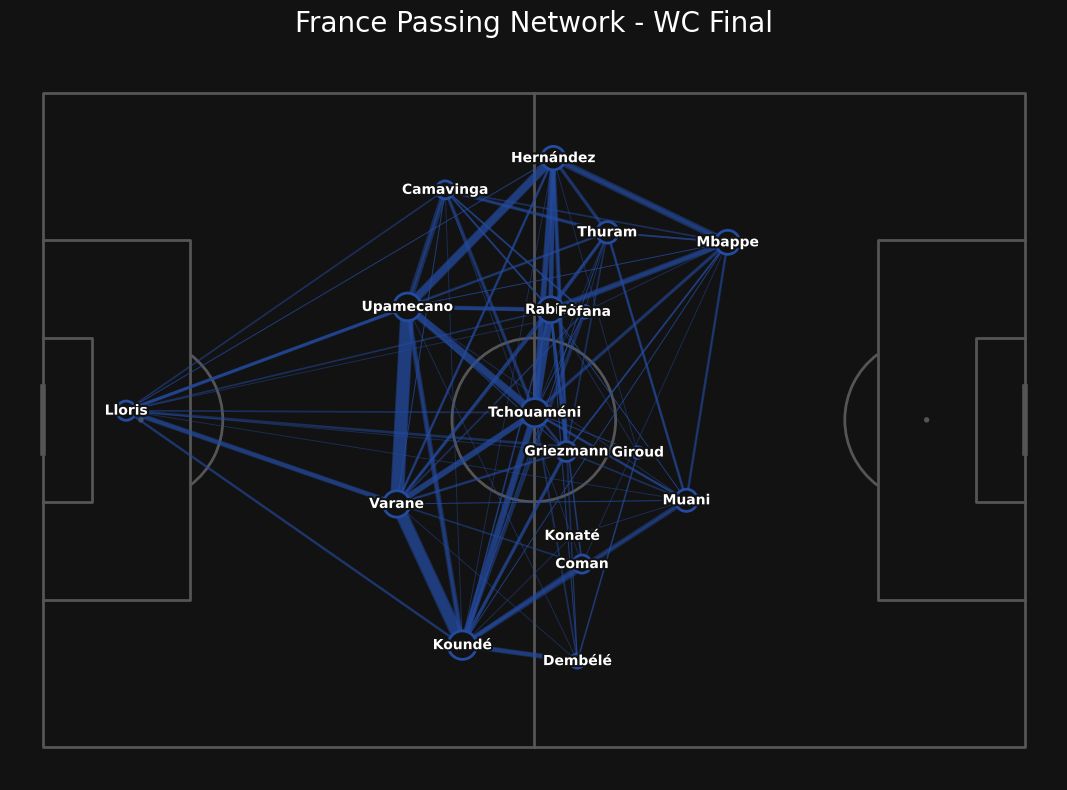

In [6]:
from matplotlib import patheffects as path_effects
import numpy as np

# 1. Filter Data for France
team_name_fra = 'France'
df_pass_fra = events[(events.type == 'Pass') & 
                     (events.team == team_name_fra) & 
                     (events.pass_outcome.isna())].copy()

# 2. Calculate Average Positions for France
# (Using the same logic as Argentina for consistency)
avg_loc_fra = events[events.team == team_name_fra].groupby('player').agg({'x': ['mean'], 'y': ['mean', 'count']})
avg_loc_fra.columns = ['x', 'y', 'count']

# 3. Filter passes between French players
pass_between_fra = df_pass_fra.groupby(['player', 'pass_recipient']).id.count().reset_index()
pass_between_fra.rename(columns={'id': 'pass_count'}, inplace=True)

# Merge locations
pass_between_fra = pass_between_fra.merge(avg_loc_fra, left_on='player', right_index=True)
pass_between_fra = pass_between_fra.merge(avg_loc_fra, left_on='pass_recipient', right_index=True, suffixes=('', '_end'))

# 4. Setup the Pitch (Flipped or same direction)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#121212', line_color='#555555')
fig, ax = pitch.draw(figsize=(13, 8))
fig.set_facecolor('#121212')

# 5. Plot the lines (Strong connections > 2 passes for France)
# We use a blue color for France
max_pass_fra = pass_between_fra.pass_count.max()
pitch.lines(pass_between_fra.x, pass_between_fra.y, pass_between_fra.x_end, pass_between_fra.y_end,
            lw=(pass_between_fra.pass_count / max_pass_fra) * 10, 
            color='#244ba0', alpha=0.5, zorder=1, ax=ax)

# 6. Plot the nodes
pitch.scatter(avg_loc_fra.x, avg_loc_fra.y, s=avg_loc_fra['count']*2,
              color='#121212', edgecolors='#244ba0', linewidth=2, zorder=2, ax=ax)

# 7. Add Player Names (Handling Mbappe and Griezmann)
for index, row in avg_loc_fra.iterrows():
    if 'Mbappé' in index:
        display_name = "Mbappe"
    elif 'Griezmann' in index:
        display_name = "Griezmann"
    else:
        display_name = index.split()[-1]
    
    pitch.annotate(display_name, xy=(row.x, row.y), c='white', va='center',
                   ha='center', size=10, weight='bold', 
                   path_effects=[path_effects.withStroke(linewidth=3, foreground='#121212')],
                   ax=ax)

plt.title(f"{team_name_fra} Passing Network - WC Final", color='white', size=20, pad=20)
plt.show()

## Phase 6: Defensive Grit & Spatial Control
> "Defense is not just about stopping the ball; it's about reclaiming the territory."

In this section, we visualize Argentina's defensive masterclass against France. Instead of complex heatmaps, we use a **Categorical Point Map** to pinpoint every successful intervention.

### 📍 Legend & Tactical Insights
* **Gold (Tackles):** Represent direct physical challenges to win the ball. High concentration on the flanks shows how Argentina neutralized French wingers.
* **Cyan (Interceptions):** Showcases the team's reading of the game. These points indicate where players cut off passing lanes before the threat developed.
* **White (Ball Recoveries):** Highlights the "Second Ball" dominance. These are moments where Argentina was fastest to react to loose balls in the midfield.

### Tactical Summary
The map reveals a **High-Intensity Press**. Argentina didn't sit back; they hunted for the ball in the middle and final thirds, forcing France into errors far from the Argentinian goal.

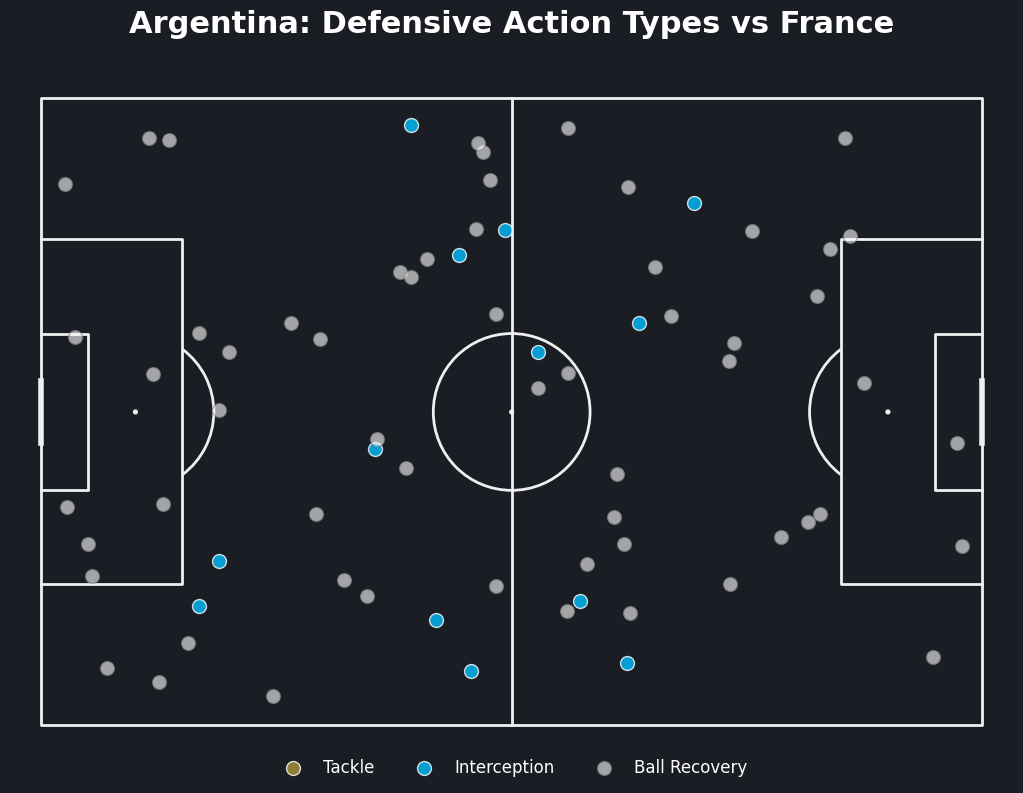

In [7]:
# 1. Prepare data
def_events = events[(events.team == 'Argentina') & 
                    (events.type.isin(['Tackle', 'Interception', 'Ball Recovery']))].copy()

def_events['x'] = def_events.location.apply(lambda loc: loc[0] if isinstance(loc, list) else None)
def_events['y'] = def_events.location.apply(lambda loc: loc[1] if isinstance(loc, list) else None)
def_events = def_events.dropna(subset=['x', 'y'])

# 2. Setup the Pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1d23', line_color='#efefef')
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#1a1d23')

# 3. Plotting with English Legend Labels
# Tackles
tackles = def_events[def_events.type == 'Tackle']
pitch.scatter(tackles.x, tackles.y, s=100, color='#ad993c', edgecolors='white', 
              label='Tackle', ax=ax, alpha=0.8)

# Interceptions
interceptions = def_events[def_events.type == 'Interception']
pitch.scatter(interceptions.x, interceptions.y, s=100, color='#00bfff', edgecolors='white', 
              label='Interception', ax=ax, alpha=0.8)

# Ball Recoveries
recoveries = def_events[def_events.type == 'Ball Recovery']
pitch.scatter(recoveries.x, recoveries.y, s=100, color='#ffffff', edgecolors='gray', 
              label='Ball Recovery', ax=ax, alpha=0.6)

# 4. Legend and Title in English
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, 
           facecolor='#1a1d23', edgecolor='none', labelcolor='white', fontsize=12)
plt.title("Argentina: Defensive Action Types vs France", color='white', size=22, pad=25, weight='bold')

plt.show()

## France: Defensive Action Types vs Argentina

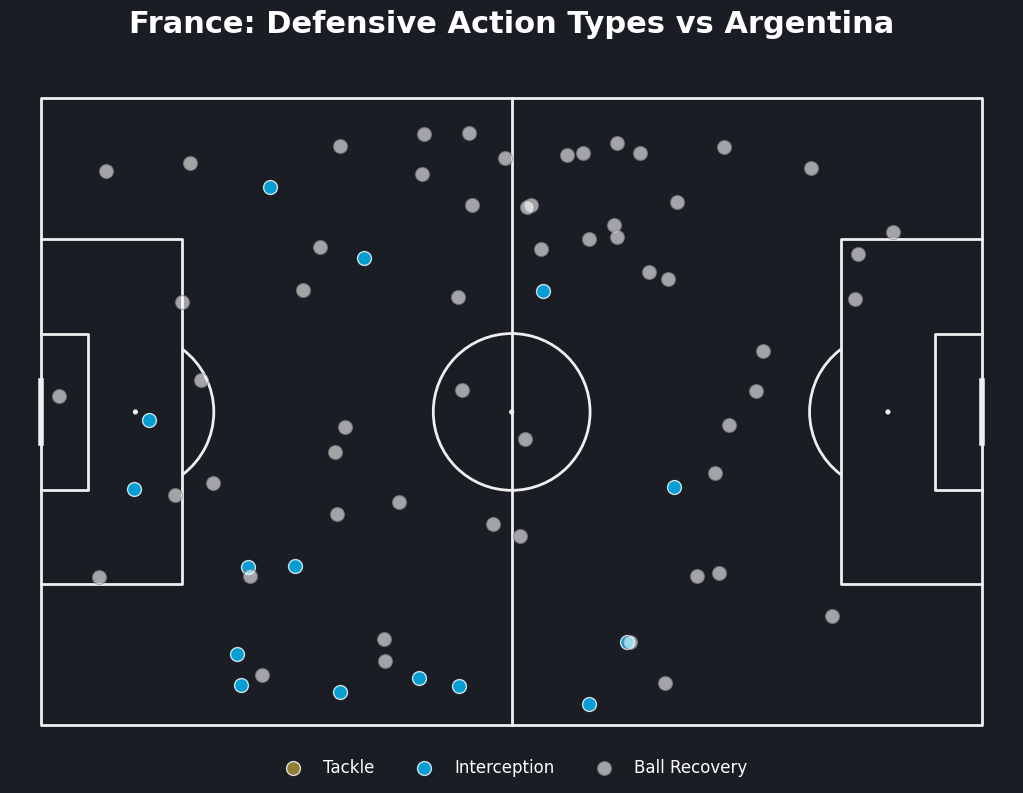

In [8]:
# 1. Prepare data
def_events = events[(events.team == 'France') & 
                    (events.type.isin(['Tackle', 'Interception', 'Ball Recovery']))].copy()

def_events['x'] = def_events.location.apply(lambda loc: loc[0] if isinstance(loc, list) else None)
def_events['y'] = def_events.location.apply(lambda loc: loc[1] if isinstance(loc, list) else None)
def_events = def_events.dropna(subset=['x', 'y'])

# 2. Setup the Pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1d23', line_color='#efefef')
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#1a1d23')

# 3. Plotting with English Legend Labels
# Tackles
tackles = def_events[def_events.type == 'Tackle']
pitch.scatter(tackles.x, tackles.y, s=100, color='#ad993c', edgecolors='white', 
              label='Tackle', ax=ax, alpha=0.8)

# Interceptions
interceptions = def_events[def_events.type == 'Interception']
pitch.scatter(interceptions.x, interceptions.y, s=100, color='#00bfff', edgecolors='white', 
              label='Interception', ax=ax, alpha=0.8)

# Ball Recoveries
recoveries = def_events[def_events.type == 'Ball Recovery']
pitch.scatter(recoveries.x, recoveries.y, s=100, color='#ffffff', edgecolors='gray', 
              label='Ball Recovery', ax=ax, alpha=0.6)

# 4. Legend and Title in English
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, 
           facecolor='#1a1d23', edgecolor='none', labelcolor='white', fontsize=12)
plt.title("France: Defensive Action Types vs Argentina", color='white', size=22, pad=25, weight='bold')

plt.show()

## Phase 7: The Last Line of Defense (Goalkeeper Exposure)
> "Games are won by strikers, but championships are saved by goalkeepers."

In this final analytical layer, we compare the "Shot Exposure" faced by **Emiliano Martínez (ARG)** and **Hugo Lloris (FRA)**. This visualization helps us understand the workload and the quality of chances each goalkeeper had to deal with.

### Key Metrics Explained:
* **Circle Size:** Represents the **Expected Goals (xG)** value of the shot. Larger circles indicate high-probability scoring chances.
* **Spatial Distribution:** Shows where the shots originated. Argentina's defense forced France into specific zones, while France had to deal with more central threats.

### Tactical Insights:
* **Emi Martínez:** The map visualizes the high-pressure moments France created late in the game, including the legendary 120th-minute save.
* **Hugo Lloris:** Faced a higher volume of shots throughout the match, reflecting Argentina's sustained offensive pressure.

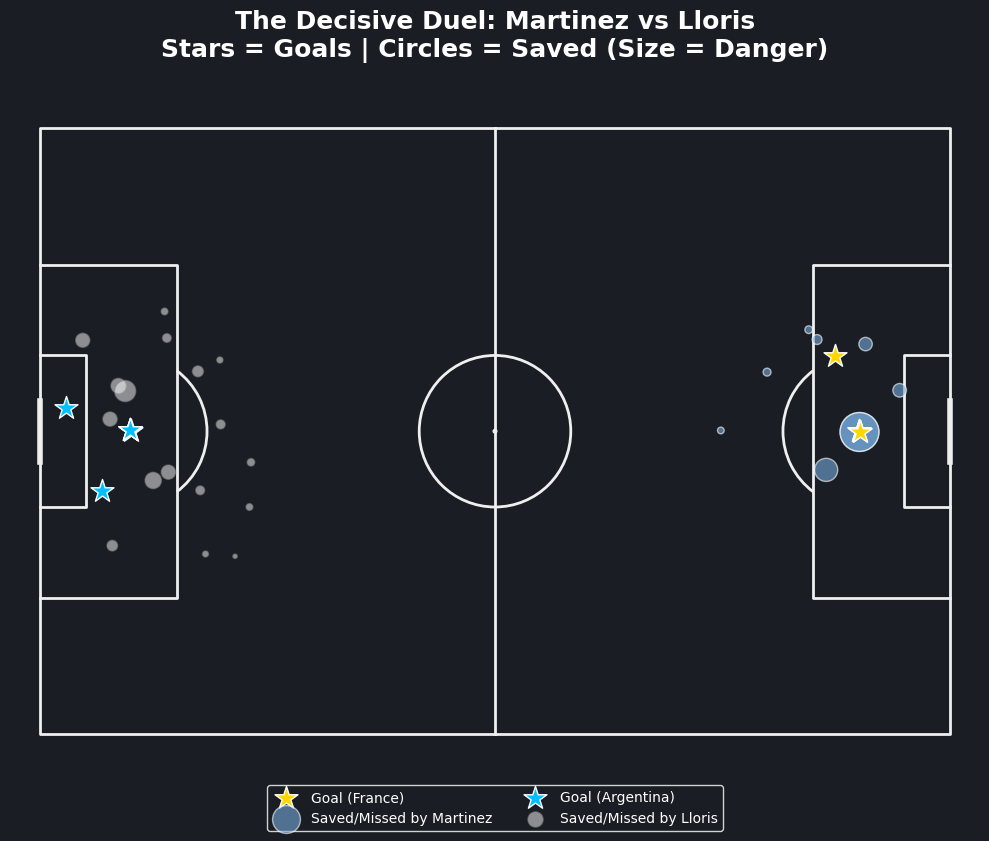

In [14]:
# Import required libraries
from statsbombpy import sb
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1. Load Match Data (World Cup Final 2022)
if 'events' not in locals():
    events = sb.events(match_id=3869685)

# 2. Prepare the data: Filter for shots and extract coordinates
shots = events[events.type == 'Shot'].copy()
shots['x'] = shots.location.apply(lambda loc: loc[0])
shots['y'] = shots.location.apply(lambda loc: loc[1])
shots['is_goal'] = shots.shot_outcome == 'Goal'

# 3. Setup a Vertical Pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1d23', line_color='#efefef')
fig, ax = pitch.draw(figsize=(10, 14))
fig.set_facecolor('#1a1d23')

# --- SECTION: EMI MARTINEZ (Argentina GK - Guarding Bottom Goal) ---
france_shots = shots[shots.team == 'France'].copy()

# Plot Goals as Golden Stars
goals_fra = france_shots[france_shots.is_goal]
pitch.scatter(goals_fra.x, goals_fra.y, s=300, marker='*', color='#ffd700', 
              edgecolors='white', label='Goal (France)', ax=ax, zorder=3)

# Plot Saves/Misses as Sky Blue Circles
saved_fra = france_shots[~france_shots.is_goal]
pitch.scatter(saved_fra.x, saved_fra.y, s=saved_fra.shot_statsbomb_xg*1000, 
              color='#75aadb', alpha=0.6, edgecolors='white', 
              label='Saved/Missed by Martinez', ax=ax, zorder=2)

# --- SECTION: HUGO LLORIS (France GK - Guarding Top Goal) ---
arg_shots = shots[shots.team == 'Argentina'].copy()

# Plot Goals as Cyan Stars
goals_arg = arg_shots[arg_shots.is_goal]
pitch.scatter(120 - goals_arg.x, 80 - goals_arg.y, s=300, marker='*', color='#00bfff', 
              edgecolors='white', label='Goal (Argentina)', ax=ax, zorder=3)

# Plot Saves/Misses as White Circles
saved_arg = arg_shots[~arg_shots.is_goal]
pitch.scatter(120 - saved_arg.x, 80 - saved_arg.y, s=saved_arg.shot_statsbomb_xg*1000, 
              color='#ffffff', alpha=0.5, edgecolors='gray', 
              label='Saved/Missed by Lloris', ax=ax, zorder=2)

# 4. Final Formatting: Moving Legend to the Bottom
# bbox_to_anchor handles the position (0.5, -0.05) moves it below the pitch
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2, 
           facecolor='#1a1d23', edgecolor='white', labelcolor='white', fontsize=10)

plt.title("The Decisive Duel: Martinez vs Lloris\nStars = Goals | Circles = Saved (Size = Danger)", 
          color='white', size=18, pad=30, weight='bold')

plt.show()

## Phase 8: Match Momentum (Cumulative xG Flow)
> "Football is a game of moments. Data shows us exactly when those moments shifted."

This visualization tracks the **Cumulative Expected Goals (xG)** over the course of the match. It acts as a "heartbeat" of the final, showing which team was creating the most dangerous chances at any given time.

### How to Read the Chart:
* **Stepped Lines:** Each "step" represents a shot taken. The higher the step, the more dangerous the chance (higher xG).
* **Blue Line (Argentina):** Shows their early dominance and steady creation of chances.
* **Dark Blue Line (France):** Visualizes their dramatic late-game surge, showing how quickly they caught up in terms of threat quality.

### Tactical Observation:
The flow chart perfectly captures the dramatic nature of the 2022 Final. You can clearly see the long periods of Argentinian control followed by the vertical, explosive spikes from the French side in the closing stages of regular and extra time.

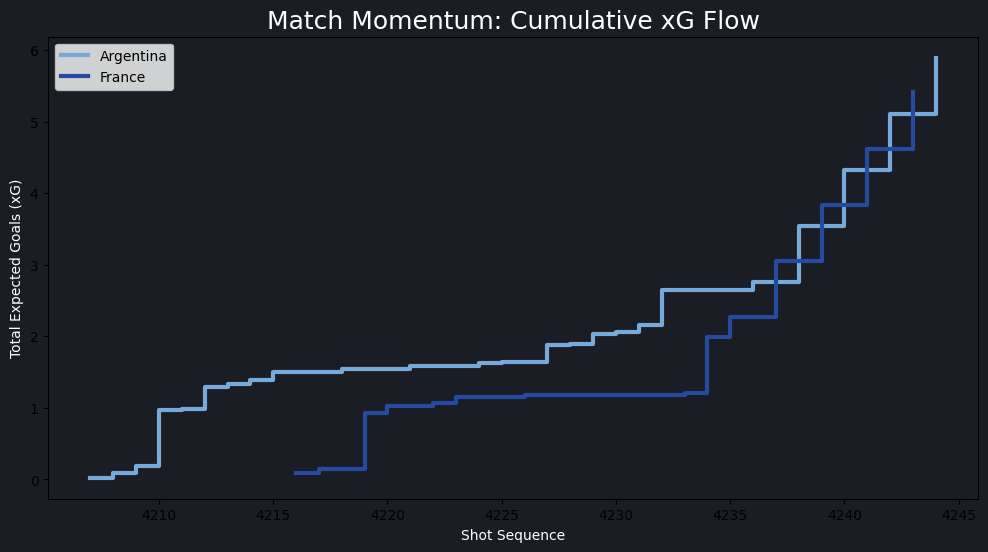

In [15]:
# Calculate cumulative xG for both teams
shots['cumulative_xg'] = shots.groupby('team')['shot_statsbomb_xg'].cumsum()

fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('#1a1d23')
ax.set_facecolor('#1a1d23')

for team in ['Argentina', 'France']:
    team_shots = shots[shots.team == team]
    color = '#75aadb' if team == 'Argentina' else '#244ba0'
    ax.step(team_shots.index, team_shots.cumulative_xg, where='post', 
            color=color, label=team, linewidth=3)

plt.title("Match Momentum: Cumulative xG Flow", color='white', size=18)
plt.xlabel("Shot Sequence", color='white')
plt.ylabel("Total Expected Goals (xG)", color='white')
plt.legend()
plt.show()